In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
with open('input/emnist_source_files/emnist-bymerge-train-images-idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    train_data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_data = train_data.reshape((size,nrows,ncols))
print('Train images shape : ',np.shape(train_data))
with open('input/emnist_source_files/emnist-bymerge-test-images-idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    test_data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_data = test_data.reshape((size,nrows,ncols))
print('Test images shape : ',np.shape(test_data))
with open('input/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    train_labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_labels = train_labels.reshape((size,))
print('Train labels shape : ',np.shape(train_labels))
with open('input/emnist_source_files/emnist-bymerge-test-labels-idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    test_labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_labels = test_labels.reshape((size,))
print('Test labels shape : ',np.shape(test_labels))

class_map = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
number_of_classes = len(class_map)
print('Class size : ', number_of_classes)


Train images shape :  (697932, 28, 28)
Test images shape :  (116323, 28, 28)
Train labels shape :  (697932,)
Test labels shape :  (116323,)
Class size :  47


Test correct image correspondence with label


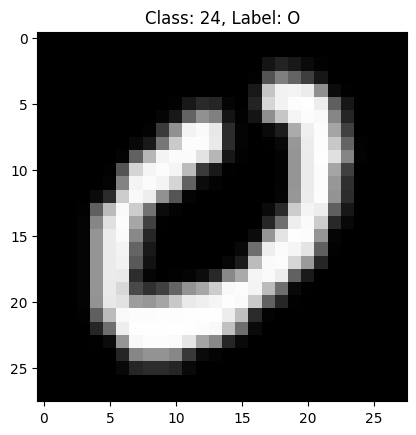

In [2]:
def show_img(data, labels, row_num):
    img_flip = np.transpose(data[row_num], axes=[1,0]) # img_size * img_size arrays
    plt.title('Class: ' + str(labels[row_num]) + ', Label: ' + str(class_map[labels[row_num]]))
    plt.imshow(img_flip, cmap='Greys_r')
print("Test correct image correspondence with label")
show_img(test_data, test_labels, 0)

In [3]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Data normalisation
train_data = train_data / 255.0
test_data = test_data / 255.0

train_data_size = train_data.shape[0]
train_data_height = 28
train_data_width = 28
train_data_img_size = train_data_height*train_data_width

train_data = train_data.reshape(train_data_size, train_data_height, train_data_width, 1)

test_data_size = test_data.shape[0]
test_data_height = 28
test_data_width = 28
test_data_img_size = test_data_height*test_data_width

test_data = test_data.reshape(test_data_size, test_data_height, test_data_width, 1)

# Transform labels
train_labels = to_categorical(train_labels, number_of_classes)
test_labels = to_categorical(test_labels, number_of_classes)
# Split some data for validation
train_data, validation_data, train_labels, validation_labels = train_test_split(train_data, train_labels, test_size=0.2, random_state=42)

print("###### Final shapes ######")
print("Train data shape : ", np.shape(train_data), "\tTrain labels shape : ", np.shape(train_labels))
print("Test data shape : ", np.shape(test_data), "\t\tTest labels shape : ", np.shape(test_labels))
print("Validation data shape : ", np.shape(validation_data), "\tValidation labels shape : ", np.shape(validation_labels))

2023-06-06 09:55:29.797195: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-06 09:55:31.192136: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-06-06 09:55:31.192200: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-06-06 09:55:31.192208: W tensorflow/com

###### Final shapes ######
Train data shape :  (558345, 28, 28, 1) 	Train labels shape :  (558345, 47)
Test data shape :  (116323, 28, 28, 1) 		Test labels shape :  (116323, 47)
Validation data shape :  (139587, 28, 28, 1) 	Validation labels shape :  (139587, 47)


In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import json

model = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32,3,input_shape=(28,28,1),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Conv2D(64,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Conv2D(128,3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    #################################################
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    #tf.keras.layers.Dense(512,activation='relu'),
    #tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=tf.keras.metrics.CategoricalAccuracy())

es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=175)
mc = ModelCheckpoint('combined_emnist_model.h5', monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True, patience=175)
history = model.fit(train_data, train_labels, batch_size=1024 , epochs=30, validation_data= (validation_data,validation_labels) , callbacks=[es,mc], verbose=0)
with open('history.json', 'w') as f:
    json.dump(history.history, f)

2023-06-06 09:55:41.287302: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-06-06 09:55:41.391444: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-06-06 09:55:41.391604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-06-06 09:55:41.394271: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF


Epoch 1: val_categorical_accuracy improved from -inf to 0.78994, saving model to combined_emnist_model.h5

Epoch 2: val_categorical_accuracy improved from 0.78994 to 0.88183, saving model to combined_emnist_model.h5

Epoch 3: val_categorical_accuracy improved from 0.88183 to 0.88185, saving model to combined_emnist_model.h5

Epoch 4: val_categorical_accuracy improved from 0.88185 to 0.88821, saving model to combined_emnist_model.h5

Epoch 5: val_categorical_accuracy improved from 0.88821 to 0.89195, saving model to combined_emnist_model.h5

Epoch 6: val_categorical_accuracy improved from 0.89195 to 0.89585, saving model to combined_emnist_model.h5

Epoch 7: val_categorical_accuracy did not improve from 0.89585

Epoch 8: val_categorical_accuracy did not improve from 0.89585

Epoch 9: val_categorical_accuracy improved from 0.89585 to 0.89868, saving model to combined_emnist_model.h5

Epoch 10: val_categorical_accuracy did not improve from 0.89868

Epoch 11: val_categorical_accuracy did 

> 90.281


/tmp/ipykernel_6885/1397094997.py:20: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,2)


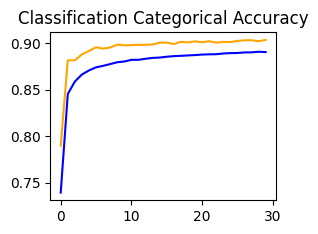

Accuracy: mean=90.281 std=0.000 n=1


In [5]:
from tensorflow.keras.models import load_model
model = load_model('combined_emnist_model.h5')

def evaluate(testX, testY, model):
    scores, histories = list(), list()
    _, acc = model.evaluate(testX, testY, verbose=0)
    print('> %.3f' % (acc * 100.0))
    scores.append(acc)
    histories.append(history)
    return scores, histories

def summarize_diagnostics(histories):
    for index in range(len(histories)):
        # LOSS
        plt.subplot(2,1,1)
        plt.title('Cross Entropy Loss')
        plt.plot(histories[index].history['loss'], color='blue', label='train')
        plt.plot(histories[index].history['val_loss'], color='orange', label='test')
        # ACCURACY
        plt.subplot(2,2,2)
        plt.title('Classification Categorical Accuracy')
        plt.plot(histories[index].history['categorical_accuracy'], color='blue', label='train')
        plt.plot(histories[index].history['val_categorical_accuracy'], color='orange', label='test')
        plt.show()

def summarize_performance(scores):
    print('Accuracy: mean=%.3f std=%.3f n=%d' % (np.mean(scores)*100, np.std(scores)*100, len(scores)))

model = load_model('combined_emnist_model.h5')
scores, histories = evaluate(test_data, test_labels, model)
summarize_diagnostics(histories)
summarize_performance(scores)